# Styles

Styles provide theme-level control over visual appearance. They affect
fonts, grids, backgrounds, and default colormaps without changing your code.

## Available Styles

SpectroChemPy includes several built-in styles:

In [1]:
import spectrochempy as scp

ds = scp.read("irdata/nh4y-activation.spg")

# List style files in the stylesheets directory
from pathlib import Path

styles_dir = Path(scp.preferences.stylesheets)
print("Available styles:")
for f in sorted(styles_dir.glob("*.mplstyle")):
    print(f"  - {f.stem}")

Available styles:
  - grayscale
  - mycustom
  - notebook
  - paper
  - poster
  - sans
  - scpy
  - serif
  - talk


## Applying a Style

Apply a style to a single plot:

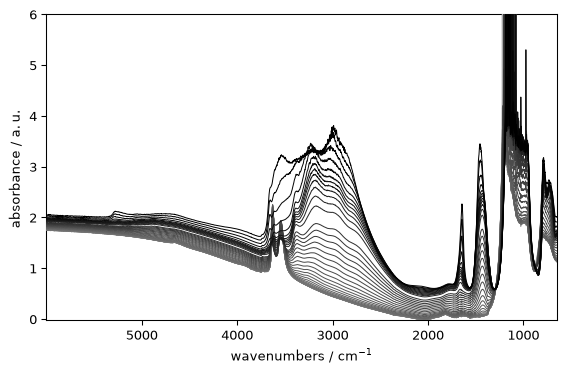

In [2]:
_ = ds.plot(style="grayscale")

## Combining Style with Options

Styles work with all other plot options:

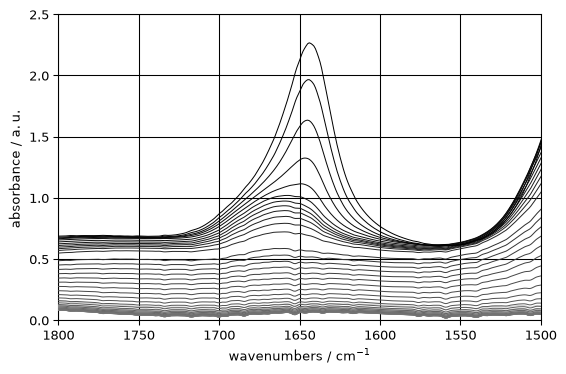

In [3]:
_ = ds.plot(style="grayscale", xlim=(1800, 1500), ylim=(0, 2.5), grid=True)

## Setting a Default Style

Make a style persistent across your session and future sessions by setting it in preferences:

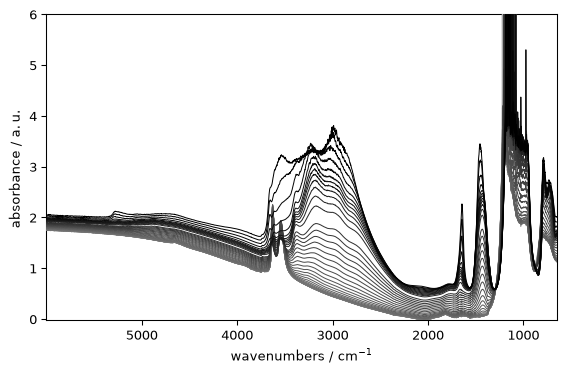

In [4]:
original_style = scp.preferences.style
scp.preferences.style = "grayscale"
_ = ds.plot()

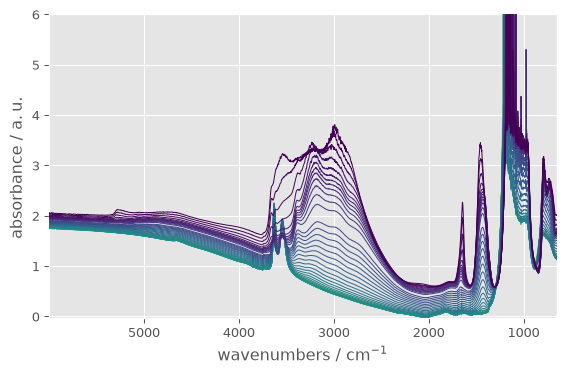

In [5]:
scp.preferences.style = "ggplot"
_ = ds.plot()

Reset to default:

In [6]:
scp.preferences.style = original_style

## Style Characteristics

| Style | Characteristics |
|-------|-----------------|
| `scpy` | Default SpectroChemPy appearance |
| `grayscale` | Grayscale colors, sets image.cmap to "gray" |
| `serif` | Serif fonts |
| `sans` | Sans-serif fonts |
| `paper` | Smaller fonts, higher DPI |
| `notebook` | Optimized for Jupyter |
| `talk` | Large fonts for presentations |
| `poster` | Very large fonts |

## Creating Custom Styles

You can create your own style based on current preferences:

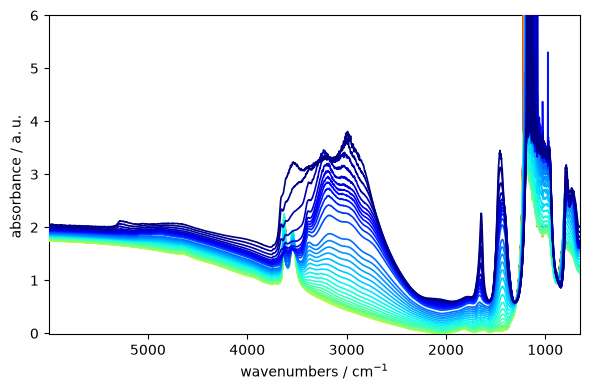

In [7]:
# Set preferences
prefs = scp.preferences
prefs.colormap_sequential = "jet"
prefs.font.family = "monospace"
prefs.font.size = 30
prefs.axes.grid = True

# Create a custom style
prefs.makestyle("mycustom")

# Reset to defaults
prefs.reset()

# Now use your custom style
_ = ds.plot(style="mycustom")

## How Styles Affect Colormaps

Styles affect colormaps only when:
1. The style explicitly sets `image.cmap` in its definition
2. `prefs.colormap` is set to "auto" (the default)

The `grayscale` style sets `image.cmap = "gray"`, so it changes the colormap
when `prefs.colormap = "auto"`. If you set a specific `prefs.colormap`, the style
will not override it.

## Best Practice

- Use **styles** for theme-level changes (publication, presentation)
- Use **kwargs** for plot-specific adjustments
- Use **preferences** for session defaults

This separation keeps your code flexible and reproducible.